In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math
#from scipy.integrate import simps
from scipy.optimize import root_scalar
import scipy.interpolate
from IPython.display import display, Markdown
from scipy.interpolate import RegularGridInterpolator
from tqdm import tqdm

Queremos resolver el sistema de ecuaciones

$$ \ddot{\phi} + 3H\dot{\phi} + V_{,\phi} = 0, \ \ H^2 = \frac{1}{3M_p^{\ 2}} \left(  \frac{1}{2}\dot{\phi}^2 + V(\phi)  \right). $$

Esto nos da dos ecuaciones diferenciales ordinarias acopladas:

$$ \ddot{\phi}  + 3 \frac{\dot{a}}{a}\dot{\phi} + V_{,\phi} = 0, \ \ \dot{a} = \frac{1}{M_p} \sqrt{\frac{1}{3}  \left(  \frac{1}{2}\dot{\phi}^2 + V(\phi)  \right)  } a $$



Empleemos el potencial Modelo T

$$   V(\phi) = \lambda M_p^{\ 4} \left[  \sqrt{6} \tanh{\left( \frac{\phi}{\sqrt{6} M_p} \right)}  \right]^k   $$

Adimencionalicemos estas ecuaciones. Sea $\bar{t} = \sqrt{\lambda}M_p t$ y $ \varphi = \phi/M_p $. Entonces


$$  \varphi'' + 3\frac{a'}{a} \varphi'  + k \left[  \sqrt{6} \tanh{\left( \frac{\varphi}{\sqrt{6}} \right)}  \right]^{k-1} \text{sech}^2{\left(  \frac{\varphi}{\sqrt{6}}\right)} = 0$$


$$  a' = \sqrt{\frac{1}{3} \left[\frac{1}{2} \varphi'^2 + \left(\sqrt{6} \tanh{\left(\frac{\varphi}{\sqrt{6}}\right)} \right)^k \right]}a  $$


donde $ ()' \equiv \frac{d}{d\bar{t}}$.

In [3]:
########### MÉTODOS NUMÉRICOS ###########
def rk4(fs,a,b,n,yinits):
    h = (b-a)/(n-1)
    xs = a + np.arange(n)*h
    ys = np.zeros((n, yinits.size))
    yvals = np.copy(yinits)
    for j,x in enumerate(xs):
        ys[j,:] = yvals
        k0 = h*fs(x, yvals)
        k1 = h*fs(x+h/2, yvals+k0/2)
        k2 = h*fs(x+h/2, yvals+k1/2)
        k3 = h*fs(x+h, yvals+k2)
        yvals += (k0 + 2*k1 + 2*k2 + k3)/6
    return xs, ys


def simpson(f,a,b,n):
    h = (b-a)/(n-1)
    xs = a + np.arange(n)*h
    cs = 2*np.ones(n)
    cs[1::2] = 4; cs[0] = 1; cs[-1] = 1
    contribs = cs*f(xs)
    return (h/3)*np.sum(contribs)

In [4]:
######################################
# PARÁMETROS DE LA SIMULACIÓN ########
######################################

N_tiempo = 1500 # NUMERO DE PASOS EN EL TIEMPO
t_min = 0 # TIEMPO MÍNIMO
t_max = 400 # TIEMPO MÁXIMO
dt = ( t_max - t_min ) / N_tiempo


######################################
####### PARÁMETROS FÍSICOS ###########
######################################


# PARA EL INFLATÓN #


phi0 = 6.37 # VALOR INICIAL DE PHI A t = 0
dphi0 = 0.0 # DERIVADA DE PHI A t = 0
a0 = 1.0 # FACTOR DE ESCALA INICIAL
k = 2 # PARÁMETRO K DEL MODELO ATRACTOR T

N0 = np.sqrt( (1/3) * (dphi0**2 + (  np.sqrt(6) * np.tanh(phi0 / np.sqrt(6))  )**k  )  )








In [5]:
# SISTEMA DE FRIEDMANN + KLEIN-GORDON #

def fss(t, yvals):
    phi, dphi, a, N = yvals
    sqrt6 = np.sqrt(6)
    tanh_phi = np.tanh(phi / sqrt6)
    H = np.sqrt((1/3) * (0.5 * dphi**2 + (sqrt6 * tanh_phi)**k))
    f0 = dphi
    f1 = - 3 * H * dphi - k * (sqrt6 * tanh_phi)**(k-1) * (1 / np.cosh(phi/sqrt6)**2)
    f2 = H * a
    f3 = H
    return np.array([f0, f1, f2, f3])


yinits = np.array([phi0, dphi0, a0, N0]) # CONDICIONES INICIALES

t, sol = rk4(fss, t_min, t_max, N_tiempo, yinits)

phi, dphi, a, N = sol[:,0], sol[:,1], sol[:,2], sol[:,3]
######################################
'Cantidades derivadas de esto'
# PARÁMETRO DE HUBBLE #
H = np.sqrt( (1/3) * (0.5 * dphi**2 + ( np.sqrt(6) * np.tanh( phi/np.sqrt(6) ) )**k )   )

# POTENCIAL #
V =  ( np.sqrt(6) * np.tanh( phi/np.sqrt(6) ) )**k 


# HORIZONTE COMÓVIL #

comoving_horizon = (1 / a*H )

# DENSIDAD DE ENERGÍA DEL INFLATÓN #
rho_phi = []

for i in range(len(t)):
    rho_phi_i = (1 / 2) * (dphi[i]**2) + ( np.sqrt(6) * np.tanh( phi[i] / np.sqrt(6) ) )**(k)
    rho_phi.append(rho_phi_i)




# DENSIDAD DE PRESIÓN DEL INFLATÓN #
P_phi = []

for i in range(len(t)):
    P_phi_i = (1 / 2) * (dphi[i]**2) - ( np.sqrt(6) * np.tanh( phi[i] / np.sqrt(6) ) )**(k)
    P_phi.append(P_phi_i)

# PARÁMETRO DE LA ECUACIÓN DE ESTADO #
omega = []

for i in range(len(t)):
    omega.append(P_phi[i] / rho_phi[i])

# DEL INFLATÓN:
m_phi_lambda = k * (   ( k - 1 )*((  np.sqrt(6)*np.tanh(phi / np.sqrt(6))  )**(k-2))*( (1 / np.cosh(phi / np.sqrt(6) ))**4 )  - (1 / 3)*( (np.sqrt(6)*np.tanh(phi / np.sqrt(6)) )**k  )*(1 / np.cosh(phi/np.sqrt(6)))**2  )  # MASA DEL INFLATÓN

m_phi_lambda_positive = []

for i in range(len(t)):
    if m_phi_lambda[i]>=0:
        m_phi_lambda_positive.append(m_phi_lambda[i])
    else:
        m_phi_lambda_positive.append(np.nan)




## Esta es la masa del inflatón dividida entre lambda y M_p^2
m_phi = np.sqrt(m_phi_lambda_positive) # En LaTeX, esto es sqrt(N)

#####################################
for t_val, phi_val, dphi_val, N_val, H_val, a_val, rho_phi_val, P_phi_val, m_phi_val in zip(t, phi, dphi, N, H, a, rho_phi, P_phi, m_phi):
    if (1/2) * (dphi_val)**2 > (np.sqrt(6) * np.tanh(phi_val / np.sqrt(6)))**k:
        phi_end, t_end, N_T, H_end, dphi_end, a_end, rho_phi_end, P_phi_end, m_phi_end = phi_val, t_val, N_val, H_val, dphi_val, a_val, rho_phi_val, P_phi_val, m_phi_val
        break

print( f'phi_end = {phi_end:.4f}, t_end = {t_end:.4f}, N_T = {N_T:.4f}, H_end = {H_end:.4f}\n'
     f'dphi_end = {dphi_end:.4f}, a_end = {a_end:e}, rho_phi_end = {rho_phi_end:.4f}, P_phi_end = {P_phi_end:.4f}')



# Normalizamos al factor de escala a 1 en t_end
a_norm = a / a_end


phi_end = 0.5732, t_end = 51.7678, N_T = 70.4140, H_end = 0.4632
dphi_end = -0.8085, a_end = 9.327729e+29, rho_phi_end = 0.6438, P_phi_end = 0.0099


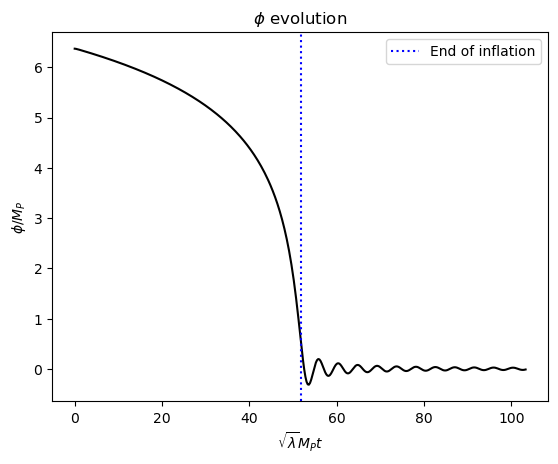

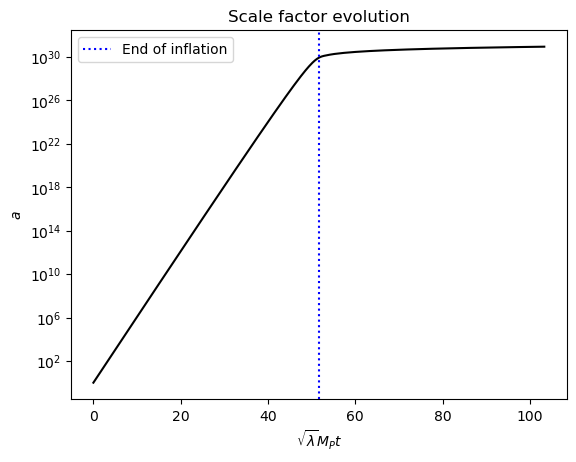

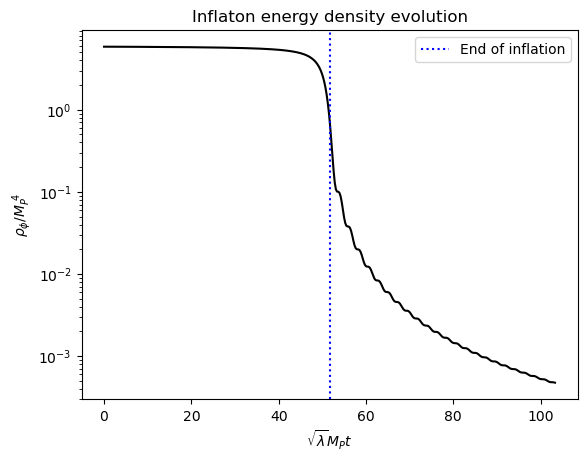

In [6]:
#plt.plot(t, comoving_horizon)
#plt.show()


plt.plot(t[t < t_end * 2], phi[t < t_end * 2], color = 'black')
plt.xlabel(r'$\sqrt{\lambda} M_P t $')
plt.ylabel(r'$ \phi / M_P$')
plt.axvline(x = t_end, color = 'blue', linestyle = 'dotted', label = 'End of inflation')
plt.title(r'$\phi$ evolution')
plt.legend()
plt.show()



plt.plot(t[t < t_end * 2], a[t < t_end * 2], color = 'black')
plt.xlabel(r'$\sqrt{\lambda} M_P t $')
plt.ylabel(r'$a$')
plt.axvline(x = t_end, color = 'blue', linestyle = 'dotted', label = 'End of inflation')
plt.title(r'Scale factor evolution')
plt.yscale('log')
plt.legend()
plt.show()

rho_phi_array = np.array(rho_phi)

plt.plot(t[t < t_end * 2], rho_phi_array[t < t_end * 2], color = 'black')
plt.xlabel(r'$\sqrt{\lambda} M_P t $')
plt.ylabel(r'$\rho_\phi/M_P^{\ 4}$')
plt.axvline(x = t_end, color = 'blue', linestyle = 'dotted', label = 'End of inflation')
plt.title(r'Inflaton energy density evolution')
plt.yscale('log')
plt.legend()
plt.show()


#plt.show()
#plt.plot(t, omega)
#plt.show()


#plt.plot(t, V)
#plt.plot(t, rho_phi)
#plt.show()


#plt.plot(t,a)
#plt.show()

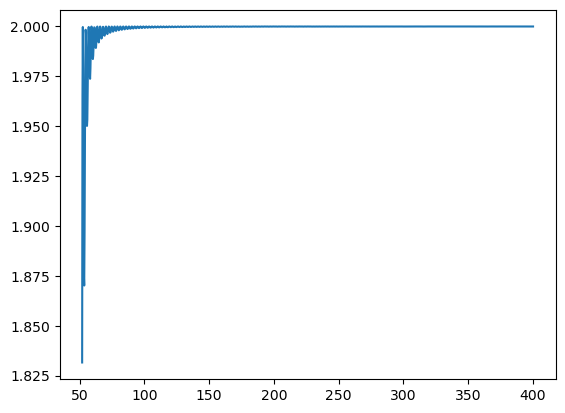

In [7]:
plt.plot(t[t>t_end], m_phi_lambda[t>t_end] )
plt.show()


In [ ]:
' Interpolemos ahora las funciones importantes para este caso '

a_t = scipy.interpolate.interp1d(t, a)
t_a = scipy.interpolate.interp1d(a, t)


H_t = scipy.interpolate.interp1d(t, H)

rho_phi_t = scipy.interpolate.interp1d(t, rho_phi)

m_phi_t = scipy.interpolate.interp1d(t, m_phi)

phi_t = scipy.interpolate.interp1d(t, phi)

a_norm_t = scipy.interpolate.interp1d(t, a_norm)

t_a_norm = scipy.interpolate.interp1d(a_norm, t)


In [9]:
' Filtremos ahora los tiempos que están después de que acaba inflación '
t_filt = []
a_filt = []
H_filt = []
phi_filt = []
rho_phi_filt = []
a_filt_norm = []
m_phi_filt = []
a_norm_filt = []


for time_val, a_val, H_val, phi_val, rho_phi_val, m_phi_val, a_norm_val  in zip(t, a, H, phi, rho_phi, m_phi, a_norm):
    if time_val >= t_end:
        t_filt.append(time_val)
        a_filt.append(a_val)
        H_filt.append(H_val)
        phi_filt.append(phi_val)
        rho_phi_filt.append(rho_phi_val)
        a_filt_norm.append(a_val / a_end)
        m_phi_filt.append(m_phi_val)
        a_norm_filt.append(a_norm_val)      


## Ecuación de Boltzmann

## Término $ \delta\phi \rightarrow \chi\chi$

Tenemos la ecuación de Boltzmann 

$$\frac{\partial f_\chi}{\partial t}  - H p \frac{\partial f_\chi}{\partial p} = \frac{\pi \left|   \overline{\mathcal{M}} \right|^2}{2 m_\phi^{\ 2} \beta(t)} \delta\left(p - m_\phi \beta(t) \right),$$

donde 

$$ \beta(t) \equiv \sqrt{ 1 - \frac{m_{eff}^{\ 2}}{m_\phi^{\ 2}}  }, $$

con $ m_{eff}^{\ 2} = m_\chi^{\ 2} + \sigma \phi(t)^2 $. Se demuestra en el artículo arXiv:2206.08940v2 que

$$  \left| \overline{\mathcal{M}} \right|^2 = \frac{1}{8} \frac{\rho_\phi^{\ 2}}{m_\phi^{\ 4}} \hat{\sigma}^2, $$

con $ \hat{\sigma} \equiv \sigma - \lambda \left( 1 + \frac{m_{eff}^{\ 2}}{2 m_\phi^{\ 2}} \right) $. Haciendo la aproximación $m_{eff}<< m_\phi$, 

$$ \frac{\partial f_\chi}{\partial t}  - H p \frac{\partial f_\chi}{\partial p} = \frac{\pi}{2 m_\phi^{\ 2}} \frac{1}{8} \frac{\rho_\phi^{\ 2}}{m_\phi^{\ 4}} (\sigma - \lambda)^2 \delta\left(p - m_\phi \right) $$

## Momento comóvil

La ecuación integrada nos da

$$  f_\chi(t, q) = \frac{\pi}{16 m_\phi^{\ 7}} \lambda^2 ( k - 1 )^2 \frac{\rho_{\phi}^{\ 2}(t_0)}{H(t_0)} \ \theta(t_0 - t_{end}) \theta(t - t_0),  $$

donde 

$$\frac{q}{a(t_0)} = m_{\phi}$$


Adimencionalizando, finalmente se llega a que

$$ \frac{df_\chi}{dt} =   \frac{\pi}{16 \lambda^2} \cdot \frac{\rho^{\ 2}_\phi(t) \hat{\sigma}^2(t) }{N^{7/2}(t)}\cdot \frac{a(t)}{\bar{q} H(t)} \delta(t - t_0)$$

$$ \Rightarrow $$

$$ f_\chi (\bar{t}, \bar{q}) = \frac{\pi}{16 \lambda^2} \cdot \frac{\rho^{\ 2}_\phi(t_0) \hat{\sigma}^2(t_0) }{N^{7/2}(t_0)}\cdot \frac{a(t_0)}{\bar{q} H(t_0)} \theta(t_0 - t_{end}) \theta(t - t_0), $$

donde $t_0$ es tal que

$$\bar{q} = a(t_0)$$

y $\bar{q} \equiv q/m_\phi$, $\bar{t} \equiv \sqrt{\lambda} M_p t$. También, $N = V_{\varphi \varphi}$, $\varphi = \phi / M_p$.

In [10]:
' Acoplamientos '
## PARA BOLTZMANN ##
# Bosones #
lambdaa = 2.5e-10
sigma = 10e-7 # IMPORTANTE, AQUÍ ESTOY HACIENDO A SIGMA GORRO CTE


m_phi_num = m_phi[-1]



In [11]:
'Discretizamos ahora al momento'
q_max = np.max(a_norm_filt)
q_min = np.min( a_norm_filt )
N_q = 200

q = np.linspace(q_min, q_max, N_q)

#print(q)


In [12]:
' Encontemos primero a t_0 '
a_0 = q # a(t_0)

t_0 = t_a_norm(a_0) # t_0. t_a es la función t(a)

#print(t_0)


In [1]:
'  Ahora encontramos a f_chi para el decaimiento de phi a dos chis '
#prefactor = ( np.pi / ( 16*(m_phi**7) ) )  * (lambdaa**2) * ( ( alpha - 1 )**2 )



prefactor = ( np.pi / ( 16 * (lambdaa**2)  ) ) * (sigma - lambdaa)**2


rho_phi_t0_2 = rho_phi_t(t_0)**2

H_t0 = H_t(t_0)

f_t0 = prefactor * rho_phi_t0_2 * ( a_t(t_0) / ( q * H_t0 ) ) / ( m_phi_t(t_0) )**7

f_chi = np.zeros((N_tiempo, N_q)) # iniciamos la función solución. Filas: tiempo, columnas: q

for i, time in enumerate(t_filt):
    for j in range(len(q)):
        if time >= t_0[j] and t_0[j] >= t_end:
            f_chi[i, j] = f_t0[j]
        else:
            f_chi[i, j] = 0.

'Ahora, escalemos a la función de distribución por q^2'
f_chi_qq = np.zeros((N_tiempo, N_q))

for time_loop in range(len(t_filt)):
    for q_loop in range(len(q)):
        f_chi_qq[time_loop, q_loop] = (q[q_loop]**2) * f_chi[time_loop, q_loop] / (2 * np.pi**2)

NameError: name 'np' is not defined

In [ ]:
%matplotlib inline
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(np.min(q)*0.8, np.max(q)*(1/0.8))
ax.set_xlabel(r'$q/m_\phi$')
ax.set_ylabel(r'$f_{\chi}  $')
ax.set_title('Evolution of f(x,t) over time')
ax.set_yscale('log')  # Mantener log
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Encontrar límites y para valores positivos
positive_values = f_chi[f_chi > 0]
if len(positive_values) > 0:
    y_min = np.min(positive_values) * 0.1
    y_max = np.max(positive_values) * 10
    ax.set_ylim(y_min, y_max)

# Usar valores absolutos y reemplazar ceros con un valor pequeño
f_chi_positive = np.where(f_chi > 0, f_chi, np.nan)

line, = ax.plot(q, f_chi_positive[0, :], 'b-', linewidth=2)

total_frames = len(t_filt)
reduction_factor = 100
total_frames_reduced = len(t_filt) // reduction_factor

def update(frame):
    actual_index = frame * reduction_factor
    if actual_index < total_frames:
        line.set_ydata(f_chi_positive[actual_index, :])
        ax.set_title(f't = {t_filt[actual_index]:.2f}' r' $\sqrt{\lambda} M_P $' '\n'
        r'$a/a_{end}$ =' f' {a_filt_norm[actual_index]:.2f}')
    else:
        line.set_ydata(f_chi_positive[-1, :])
        ax.set_title(f't = {t_filt[-1]:.2f}' r' $\sqrt{\lambda} M_P $' '\n'
        r'$a/a_{end}$ ='  f' {a_filt_norm[-1]:.2f}')
    return line,

ani = animation.FuncAnimation(
    fig = fig,
    func = update,
    frames = total_frames_reduced,
    interval = 50,  # 50 ms es mejor
    blit = True,
    repeat = True
)

#try: os.remove()
#print(f"File '{file_path}' deleted successfully.")

ani.save('f_chi_evolution_q.gif', 
             writer='pillow',      # Usar Pillow para GIF
             fps = 50,               # Frames por segundo
             dpi = 100,              # Resolución
             bitrate = 1800)         # Calidad

plt.close(fig)

In [15]:
%matplotlib inline
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(np.min(q)*0.8, np.max(q)*(1/0.8))
ax.set_xlabel('q')
ax.set_ylabel(r'$ q^2 \ f_{\chi}$')
ax.set_title('Evolution of f(x,t) over time')
ax.set_yscale('log')  # Mantener log
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Encontrar límites y para valores positivos
positive_values = f_chi_qq[f_chi_qq > 0]
if len(positive_values) > 0:
    y_min = np.min(positive_values)*0.1
    y_max = np.max(positive_values) * 10
    ax.set_ylim(y_min, y_max)

# Usar valores absolutos y reemplazar ceros con un valor pequeño
f_chi_positive = np.where(f_chi_qq > 0, f_chi_qq, np.nan)

line, = ax.plot(q, f_chi_positive[0, :], 'b-', linewidth=2)

total_frames = len(t_filt)
reduction_factor = 100
total_frames_reduced = len(t_filt) // reduction_factor

def update(frame):
    actual_index = frame * reduction_factor
    if actual_index < total_frames:
        line.set_ydata(f_chi_positive[actual_index, :])
        ax.set_title(f't = {t_filt[actual_index]:.2f}' r' $\sqrt{\lambda} M_P $' '\n'
        r'$a/a_{end}$ =' f' {a_filt_norm[actual_index]:.2f}')
    else:
        line.set_ydata(f_chi_positive[-1, :])
        ax.set_title(f't = {t_filt[-1]:.2f}' r' $\sqrt{\lambda} M_P $' '\n'
        r'$a/a_{end}$ ='  f' {a_filt_norm[-1]:.2f}')
    return line,

ani = animation.FuncAnimation(
    fig = fig,
    func = update,
    frames = total_frames_reduced,
    interval = 50,  # 50 ms es mejor
    blit = True,
    repeat = True
)

#try: os.remove()
#print(f"File '{file_path}' deleted successfully.")

ani.save('f_chi_evolution_qq.gif', 
             writer='pillow',      # Usar Pillow para GIF
             fps = 50,               # Frames por segundo
             dpi = 100,              # Resolución
             bitrate = 1800)         # Calidad

plt.close(fig)

In [16]:
print(m_phi)

[       nan        nan        nan ... 1.41421304 1.41421145 1.41420965]


## Término $\phi \rightarrow \chi\chi  + \chi \chi \rightarrow  \psi \psi$

El término a añadir es

$$ \mathcal{C}[f_\chi] = - \frac{\sigma y^2 \phi^2}{8(2\pi)^2 p^2}f_\chi(t,p) \int_0^{m_\phi} \frac{dp'}{p'} f_\chi(t,p') \times \left\{   \frac{m_\phi}{\Gamma_\phi} \left[  a \cot{\left(   \frac{\Gamma_\phi}{m_\phi} \right) } - a\cot{  \left( \frac{m_\phi \Gamma_\phi}{m_\phi^{\ 2 } - 4pp' } \right)  }  \right] +  \frac{1}{2} \left[ \frac{ (m_\phi^{\ 2} - 4pp')^2 + m_\phi^{\ 2}\Gamma_\phi^{\ 2} }{m_\phi^{\ 2} (m_\phi^{\ 2} + \Gamma_\phi^{\ 2})  } \right]  \right\} $$

Si adimencionalizamos, tenemos 

$$  \frac{df_\chi}{d\bar{t}} = \frac{\pi}{16\lambda^2} \cdot \frac{\rho_\phi (\bar{t})^2 (\sigma - \lambda)^2}{N(\bar{t})^{7/2}}\cdot \frac{a(\bar{t})}{\bar{q} H(\bar{t})}\delta( \bar{t} - t_0 )  - \frac{\sigma^2 y^2}{8 (2\pi)^3}  \cdot \frac{1}{\lambda \sqrt{N}} \cdot \frac{\varphi^2}{\bar{q^2}} a(\bar{t}) \cdot f_\chi(\bar{t}, \bar{q}) \int_0^{\bar{q}_{max} / a(\bar{t})} d\bar{q'} \ f_\chi(\bar{t}, \bar{q'}) \cdot g(\bar{t}, \bar{q}, \bar{q'} ), $$

donde 

$$ g(\bar{t}, \bar{q}, \bar{q'}) =   \frac{1}{\Gamma_\phi'}\left[   \arctan{\left(   \frac{\Gamma_\phi'}{1 - 4\bar{q}\bar{q'}/a^2(\bar{t})}  \right)} - \arctan{\left(  \Gamma_\phi'  \right)}  \right]  + \frac{1}{2} \ln{ \left[  \frac{ ( 1 - 4\bar{q}\bar{q'}/a^2(\bar{t}) )^{2} + \Gamma_\phi'^{\ 2} }{1 + \Gamma_\phi'^{\ 2}}  \right]}    $$

y $t_0$ es tal que

$$ \bar{q} = a(t_0). $$

Las constantes están dadas por $ \Gamma_\phi' = \Gamma_\phi/m_\phi = \frac{y^2}{8\pi} $. 

Si integramos de $\bar{t}_{end}$ a $\bar{t}$, llegamos a que


$$ f_{\chi}(\bar{t}, \hat{q} ) =  \frac{\pi}{16\lambda^2}\cdot \frac{\rho_\phi(t_0)^2 \hat{\sigma}^2(t_0)}{N(t_0)^{7/2}} \cdot \frac{\hat{a}(t_0)}{\hat{q}H(t_0)} \theta(t_0 - t_{end})\theta(\bar{t} - t_0) - \frac{\sigma^2 y^2}{8 (2\pi)^3}\cdot \frac{1}{\lambda \hat{q}^2}\int_{t_{end}}^{\bar{t}}dt' \frac{\varphi(t')^2 \hat{a}(t') }{\sqrt{N(t')}} f_{\chi}(t', \hat{q}) \int_0^{q_{max}} d\hat{q}' f_\chi(t', \hat{q}') g(t', \hat{q}, \hat{q}'),$$

con 


$$  g(\bar{t}, \hat{q}, q') =   \frac{1}{\Gamma_\phi'}\left[   \arctan{\left(   \frac{\Gamma_\phi'}{1 - 4\hat{q}\hat{q}'/\hat{a}^2(\bar{t})}  \right)} - \arctan{\left(  \Gamma_\phi'  \right)}  \right]  + \frac{1}{2} \ln{ \left[  \frac{ ( 1 - 4\hat{q}\hat{q}'/\hat{a}^2(\bar{t}) )^{2} + \Gamma_\phi'^{\ 2} }{1 + \Gamma_\phi'^{\ 2}}  \right]},    $$

donde $ \hat{q} = q/(a_{end}m_\phi) $, $\hat{a} = a / a_{end}$ y $t_0$ es tal que 


$$ \hat{q} = \hat{a}(t_0).  $$

Durante este periodo, la dinámica está dada por

$$\dot{\rho_\phi} + 3 H\rho_\phi + \Gamma_\phi \rho_\phi = 0$$
$$  \dot{\rho_\psi} + 4 H\rho_\psi - \Gamma_\phi = 0$$
$$  \rho_\phi + \rho_\psi = 3H^2 M_P^{\ 2}  $$

O bien, usando $\bar{t} = \sqrt{\lambda} M_P t$, tenemos que

In [17]:
def H_reh(rho_phi, rho_psi):
    return np.sqrt( (1/3*lambdaa) * ( rho_phi + rho_psi )  )


def reheating_system(x, y_sol, y):
    rho_phi_reh, rho_psi_reh, a_reh = y_sol
    H_value = H_reh(rho_phi_reh, rho_psi_reh)
    Gamma = (y**2 / (8 * np.pi))
    m_phi_value = m_phi_num

    drho_phi_dt = - (3 * H_value + Gamma * (m_phi_value / np.sqrt(lambdaa)) ) * rho_phi_reh

    drho_psi_dt = - 4 * H_value * rho_psi_reh + Gamma * (m_phi_value / np.sqrt(lambdaa)) * rho_phi_reh

    da_dt = a_reh * H_value

    return np.array([drho_phi_dt, drho_psi_dt, da_dt])

def solve_reh_system(y, a, b, N_reh_T, yinits):
    def system(x, y_sol):
        return reheating_system(x, y_sol, y)
    
    t_reh, solution = rk4(system, a, b, N_reh_T, yinits)

    rho_phi_reh = solution[:, 0]
    rho_psi_reh = solution[:, 1]
    a_reh = solution[:, 2]  

    H_reheat = H_reh(rho_phi_reh, rho_psi_reh)

    return t_reh, rho_phi_reh, rho_psi_reh, a_reh, H_reheat

#yinits = np.array([rho_phi_end, 0., a_end])
#sol = solve_reh_system(1e-6, t_end, t_max, 1000, yinits)


In [18]:
'Redefinimos la malla'
#q_min = np.min(a_norm_filt) #Tengo que ver si conviene este q_min

q2_min = np.min(a_norm_filt)

q2_max = np.max(a_norm_filt) #Tengo que ver si conviene este q_max
N2_q = 1000

q2 = np.linspace(q2_min, q2_max, N2_q)



#rho_phi_avaraged_t = scipy.interpolate.interp1d(t, rho_phi_avaraged)

q2 = np.array(q2)


t_00 = t_a_norm(q2) # Esto es t_0. El doble cero viene para diferenciarlo del t_0 del caso anterior

# Acoplamiento Yukawa (ya es adimensional):

#y = 1e-6 ##

# Razón de decaimiento adimensionalizada
#Gamma = (y**2 / (8*np.pi))

In [19]:
# Debemos definir algunas funciones
# Primero, el 1er término es:

def termino1(t, q, sigma):
    resultado = np.zeros((N_tiempo, N2_q))

    
    prefac1 = (np.pi/(16*lambdaa**2)) * (sigma - lambdaa)**2

    for i, t_val in enumerate(t):
        for j, q_val in enumerate(q):
            if t_00[j] >= t_end and t_00[j] <= t_val:
                resultado[i, j] = ((rho_phi_t(t_00[j])**2 ) *a_norm_t(t_00[j]) ) * ( 1 / m_phi_t(t_00[j])**7  ) * ( 1 / (  q_val * H_t(t_00[j])  ) )
            else:
                pass

    resultado = prefac1 * resultado

    return resultado


#def arccot(x):
#    return np.arctan(1/x)


# El integrando es el siguiente. q1 es q', la variable de integración.

def g(t, q, q1, y):
    Gamma = (y**2 / (8*np.pi))
    return (1 / Gamma) * (    np.arctan((Gamma) / (  1 - 4*( q*q1 /a_norm_t(t)**2 )   ))   - np.arctan(Gamma) ) + (1 / 2) * np.log(  ((1 - 4*( q*q1 / (a_norm_t(t)**2) ) )**2 + Gamma**2)  / (1 + Gamma**2)  ) + np.exp(t)

#def g(t, q, q1, y):
#    Gamma = (y**2 / (8*np.pi))
#    return (1 / Gamma) * (  -  arccot((Gamma) / (  1 - 4*( q*q1 /a_norm_t(t)**2 )   ))   + arccot(Gamma) ) + (1 / 2) * np.log(  ((1 - 4*( q*q1 / (a_norm_t(t)**2) ) )**2 + Gamma**2)  / (1 + Gamma**2)  )


# El prefactor del segundo término es

# La solución está dada por

def solucion2(t, q, sigma, y):
    N_tiempo = len(t) # Número de nodos en la malla de tiempo
    N2_q = len(q) # Número de nodos en la malla de momento comóvil


    resultado = np.zeros((N_tiempo, N2_q)) # Creamos la solución como una matriz de ceros. Las filas son el tiempo y las columnas moemnto comóvil
    N_int_t = 100 
    N_int_q = 80 

    factor_mult = 1

    
    def closest(list, target):
        return min(list, key = lambda x: abs(x - target))
    
    t_end_c = closest(t, t_end)

    term1 = termino1(t, q, sigma)

    with tqdm(total = len(t), desc ='Procesando') as pbar: 
        for i, t_val in enumerate(t): # Fijamos un tiempo de la función f_chi
            if t_val < t_end_c: # 
                pbar.update(1)
                continue
            
            t_int = np.linspace(t_end, t_val, N_int_t)

            for j, q_val in enumerate(q):
                

                if t_val == t_end_c:
                    resultado[i, j] = term1[i, j]

                elif t_val > t_end:
                    
                    prefac2 = - ( ( (sigma**2)*(y**2) ) / (8* lambdaa *(2*np.pi)**3)  ) * factor_mult

                    integrando_t_array = []


                    for k, t_val_int in enumerate(t_int):
                        q_int = np.linspace(0., q_max / a_norm_t(t_val_int), N_int_q)
                        
                        tiempos_calculados = t[:i]
                        t_prime_index = np.argmin(np.abs(tiempos_calculados - t_val_int))

                        f_interp_t_val_int = scipy.interpolate.interp1d(q,
                                                                        resultado[t_prime_index, :],
                                                                        bounds_error=False, 
                                                                        fill_value=0.)
                        
                        f_qprime = f_interp_t_val_int(q_int)

                        integrando_q = f_qprime * g(t_val_int, q_val, q_int, y)

                        integral_q = np.trapz(integrando_q, q_int)



                        f_inter_q_val_fixed = scipy.interpolate.interp1d(t[:i], 
                                                                    resultado[:i, j], 
                                                                    bounds_error=False, 
                                                                    fill_value = 0.)
                    
                        f_tprime = f_inter_q_val_fixed(t_val_int)

                        integrando_t = (a_norm_t(t_val_int) * (phi_t(t_val_int)**2) / m_phi_t(t_val_int) )  * f_tprime *integral_q 

                        integrando_t_array.append(integrando_t)

                    integral_t = np.trapz(integrando_t_array, t_int)

                    termino2 = prefac2 * integral_t * (1 / q_val**2)

                    resultado[i, j] = term1[i, j] + termino2
            pbar.update(1)
            pbar.set_postfix({'Completado': f'{i+1}/{len(t)}'})
        
        #print(f'Progreso: {i+1}/{len(t)} ', end='\r')

    return resultado


def soloi(sigma):
    return termino1(t, q2, sigma)

def solij(sigma, y):
    return solucion2(t, q2, sigma, y)

In [20]:
# Debemos definir algunas funciones
# Primero, el 1er término es:

def termino1(t, q, sigma, y):
    
    

    resultado = np.zeros((N_tiempo, N2_q))
    Gamma = y**2/(8 * np.pi)
    rho_phi_avaraged = []
    rho_phi_avaraged[:] = rho_phi_end * (a_norm[:])**(-6*k / (k + 2)) * np.exp(  - Gamma * (  m_phi[:] / np.sqrt(lambdaa)  ) * (t[:] - t_end) )
    rho_phi_avaraged_t = scipy.interpolate.interp1d(t, rho_phi_avaraged)
    
    prefac1 = (np.pi/(16*lambdaa**2)) * (sigma - lambdaa)**2
    with tqdm(total = len(t), desc ='Procesando') as pbar:
        for i, t_val in enumerate(t):
            for j, q_val in enumerate(q):
                if t_00[j] >= t_end and t_00[j] <= t_val:
                    resultado[i, j] = ((rho_phi_avaraged_t(t_00[j])**2 ) *a_norm_t(t_00[j]) ) * ( 1 / m_phi_t(t_00[j])**7  ) * ( 1 / (  q_val * H_t(t_00[j])  ) )
                else:
                    pass
            pbar.update(1)
            pbar.set_postfix({'Completado': f'{i+1}/{len(t)}'})

    resultado = prefac1 * resultado

    return resultado


#def arccot(x):
#    return np.arctan(1/x)


# El integrando es el siguiente. q1 es q', la variable de integración.

def g(t_index, q, q1, y):
    Gamma = (y**2 / (8*np.pi))
    return (1 / Gamma) * (    np.arctan((Gamma) / (  1 - 4*( q*q1 /a_norm[t_index]**2 )   ))   - np.arctan(Gamma) ) + (1 / 2) * np.log(  ((1 - 4*( q*q1 / (a_norm[t_index]**2) ) )**2 + Gamma**2)  / (1 + Gamma**2)  )




# La solución está dada por

def solucion3(t, q, sigma, y):
    N_tiempo = len(t) # Número de nodos en la malla de tiempo
    N2_q = len(q) # Número de nodos en la malla de momento comóvil


    resultado = np.zeros((N_tiempo, N2_q)) # Creamos la solución como una matriz de ceros. Las filas son el tiempo y las columnas moemnto comóvil


    prefac2 = - ( ( (sigma**2)*(y**2) ) / (8* lambdaa *(2*np.pi)**3)  ) # El prefactor del término 2

    
    def closest(list, target):
        return min(list, key = lambda x: abs(x - target))
    
    t_end_c = closest(t, t_end) 

    term1 = termino1(t, q, sigma, y) # Se calcula el 1er término

    with tqdm(total = len(t), desc ='Procesando') as pbar: 
        for i, t_val in enumerate(t): # Fijamos un tiempo de la función f_chi
            if t_val < t_end_c: # 
                pbar.update(1)
                continue # No se hace nada si el t < t_end
            
            t_int = t[(t >= t_end) & (t <= t_val)] # Este es el tiempo de integración
            t_int_index = np.where((t >= t_end) & (t <= t_val))[0] # Estos son los índices de integración

            for j, q_val in enumerate(q):
                

                if t_val == t_end_c: # Si t = t_end, se toma el primer término sólamente para el valor de f_chi
                    resultado[i, j] = term1[i, j] # Sólo se toma el primer valor

                elif t_val > t_end: # Para t > t_end 
                    

                    integrando_t_array = np.zeros(len(t_int)) # Definimos el valor del integrando en la int dt'


                    for k, t_index_val in enumerate(t_int_index): # Para los índices del integrando, k es el índice de el numeramiento actual
                                                                  # y t_index_val el valor del índice de los t_int
                                                                  # Básicamente, si se evalúa una lista temporal en t_index_val, se tiene
                                                                  # el valor asociado a ese tiempo
                        t_val_int = t[t_index_val] # El valor actual del tiempo


                        qp_max = q.max() # Este es el límite superior de la integral dq'
                        
                        qp_index = np.where((q >= 0 ) & (q <= qp_max))[0] # Son los índices que están en nuestra malla q que están dentro 
                                                                          # de los límites de integración 

                        
                        
                        f_qprime = resultado[t_index_val, qp_index] # Se toma el valor anteriormente calculado

                        g_vals = g(t_index_val, q_val, q[qp_index], y) # El valor de la función g del integrando en dq' 

                        integrando_q = f_qprime * g_vals # El valor del integrando en dq'

                        integral_q = np.trapz(integrando_q, q[qp_index]) # Se realiza la integral dq'

                        f_tprime = resultado[t_index_val, j] # Calcula el valor de la función f_chi al tiempo t_index_val de la integral dt'


                        integrando_t_array[k] = (a_norm[t_index_val] * (phi[t_index_val]**2) / m_phi[t_index_val] ) * f_tprime * integral_q # Añade al array del
                                                                                                                                            # integrando en dt'





                    
                    if len(t_int_index) > 1:
                        integral_t = np.trapz(integrando_t_array, t[t_int_index]) # Realiza la integral dt'
                    else:
                        integral_t = 0.


                    termino2 = prefac2 * integral_t * (1 / q_val**2) # El valor del segundo término a los valores t y q fijos

                    resultado[i, j] = term1[i, j] + termino2 # Añade el valor a este array
            pbar.update(1)
            pbar.set_postfix({'Completado': f'{i+1}/{len(t)}'})
        
        #print(f'Progreso: {i+1}/{len(t)} ', end='\r')

    return resultado


def soloi(sigma, y):
    return termino1(t, q2, sigma, y)

def sol3ij(sigma, y):
    return solucion3(t, q2, sigma, y)

In [ ]:
# Debemos definir algunas funciones
# Primero, el 1er término es:

def termino1(t, sigma, y):

    N_reh_T = int(math.ceil(t_max - t_end)*1.5)
    yinits = np.array([rho_phi_end, 0., a_end])
    solution = solve_reh_system(y, t_end, t_max, N_reh_T, yinits)
    t_reh, rho_phi_reh, rho_psi_reh, a_reh, H_reh = solution[0], solution[1], solution[2], solution[3], solution[4] 

    a_reh_norm = a_reh / a_end

    rho_phi_reh_t = scipy.interpolate.interp1d(t_reh, rho_phi_reh)
    H_reh_t = scipy.interpolate.interp1d(t_reh, H_reh)
    a_reh_t = scipy.interpolate.interp1d(t_reh, a_reh)
    a_reh_norm_t = scipy.interpolate.interp1d(t_reh, a_reh/a_end)
    t_a_reh = scipy.interpolate.interp1d(a_reh, t_reh)
    t_a_reh_norm = scipy.interpolate.interp1d(a_reh/a_end, t_reh)

    
    q_min =  np.min(a_reh_norm)
    q_max = np.max(a_reh_norm)

    N_q = 1000

    q = np.linspace(q_min, q_max, N_q)


    t_0 = t_a_reh_norm(q)

    resultado = np.zeros((N_tiempo, N2_q))
    Gamma = y**2/(8 * np.pi)
    
    prefac1 = (np.pi/(16*lambdaa**2)) * (sigma - lambdaa)**2
    with tqdm(total = len(t), desc ='Procesando') as pbar:
        for i, t_val in enumerate(t):
            for j, q_val in enumerate(q):
                if t_0[j] >= t_end and t_0[j] <= t_val:
                    resultado[i, j] = ((rho_phi_reh_t(t_0[j])**2 ) *a_reh_norm_t(t_0[j]) ) * ( 1 / m_phi_t(t_0[j])**7  ) * ( 1 / (  q_val * H_reh_t(t_0[j])  ) )
                else:
                    pass
            pbar.update(1)
            pbar.set_postfix({'Completado': f'{i+1}/{len(t)}'})

    resultado = prefac1 * resultado

    return resultado, q


#def arccot(x):
#    return np.arctan(1/x)


# El integrando es el siguiente. q1 es q', la variable de integración.

def g(t_index, q, q1, y):
    Gamma = (y**2 / (8*np.pi))
    return (1 / Gamma) * (    np.arctan((Gamma) / (  1 - 4*( q*q1 /a_norm[t_index]**2 )   ))   - np.arctan(Gamma) ) + (1 / 2) * np.log(  ((1 - 4*( q*q1 / (a_norm[t_index]**2) ) )**2 + Gamma**2)  / (1 + Gamma**2)  )




# La solución está dada por

def solucion3(t, q, sigma, y):
    N_tiempo = len(t) # Número de nodos en la malla de tiempo
    N2_q = len(q) # Número de nodos en la malla de momento comóvil


    resultado = np.zeros((N_tiempo, N2_q)) # Creamos la solución como una matriz de ceros. Las filas son el tiempo y las columnas moemnto comóvil


    prefac2 = - ( ( (sigma**2)*(y**2) ) / (8* lambdaa *(2*np.pi)**3)  ) # El prefactor del término 2

    
    def closest(list, target):
        return min(list, key = lambda x: abs(x - target))
    
    t_end_c = closest(t, t_end) 

    term1 = termino1(t, q, sigma, y) # Se calcula el 1er término

    with tqdm(total = len(t), desc ='Procesando') as pbar: 
        for i, t_val in enumerate(t): # Fijamos un tiempo de la función f_chi
            if t_val < t_end_c: # 
                pbar.update(1)
                continue # No se hace nada si el t < t_end
            
            t_int = t[(t >= t_end) & (t <= t_val)] # Este es el tiempo de integración
            t_int_index = np.where((t >= t_end) & (t <= t_val))[0] # Estos son los índices de integración

            for j, q_val in enumerate(q):
                

                if t_val == t_end_c: # Si t = t_end, se toma el primer término sólamente para el valor de f_chi
                    resultado[i, j] = term1[i, j] # Sólo se toma el primer valor

                elif t_val > t_end: # Para t > t_end 
                    

                    integrando_t_array = np.zeros(len(t_int)) # Definimos el valor del integrando en la int dt'


                    for k, t_index_val in enumerate(t_int_index): # Para los índices del integrando, k es el índice de el numeramiento actual
                                                                  # y t_index_val el valor del índice de los t_int
                                                                  # Básicamente, si se evalúa una lista temporal en t_index_val, se tiene
                                                                  # el valor asociado a ese tiempo
                        t_val_int = t[t_index_val] # El valor actual del tiempo


                        qp_max = q.max() # Este es el límite superior de la integral dq'
                        
                        qp_index = np.where((q >= 0 ) & (q <= qp_max))[0] # Son los índices que están en nuestra malla q que están dentro 
                                                                          # de los límites de integración 

                        
                        
                        f_qprime = resultado[t_index_val, qp_index] # Se toma el valor anteriormente calculado

                        g_vals = g(t_index_val, q_val, q[qp_index], y) # El valor de la función g del integrando en dq' 

                        integrando_q = f_qprime * g_vals # El valor del integrando en dq'

                        integral_q = np.trapz(integrando_q, q[qp_index]) # Se realiza la integral dq'

                        f_tprime = resultado[t_index_val, j] # Calcula el valor de la función f_chi al tiempo t_index_val de la integral dt'


                        integrando_t_array[k] = (a_norm[t_index_val] * (phi[t_index_val]**2) / m_phi[t_index_val] ) * f_tprime * integral_q # Añade al array del
                                                                                                                                            # integrando en dt'





                    
                    if len(t_int_index) > 1:
                        integral_t = np.trapz(integrando_t_array, t[t_int_index]) # Realiza la integral dt'
                    else:
                        integral_t = 0.


                    termino2 = prefac2 * integral_t * (1 / q_val**2) # El valor del segundo término a los valores t y q fijos

                    resultado[i, j] = term1[i, j] + termino2 # Añade el valor a este array
            pbar.update(1)
            pbar.set_postfix({'Completado': f'{i+1}/{len(t)}'})
        
        #print(f'Progreso: {i+1}/{len(t)} ', end='\r')

    return resultado


def soloi(sigma, y):
    return termino1(t, sigma, y)

#def sol3ij(sigma, y):
#    return solucion3(t, sigma, y)

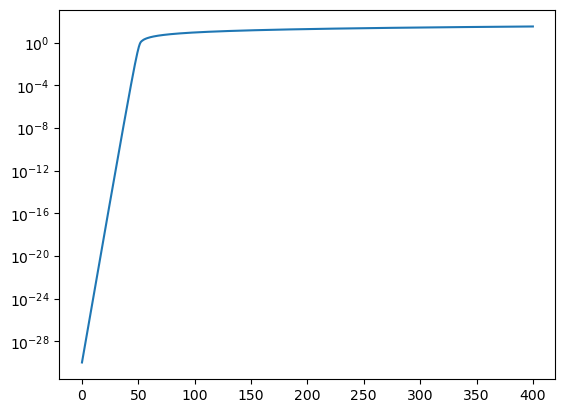

In [22]:
plt.plot(t, a_norm)
plt.yscale('log')
plt.show()

Procesando: 100%|██████████| 1500/1500 [00:35<00:00, 41.75it/s, Completado=1500/1500]


(array([[     0.        ,      0.        ,      0.        , ...,
             0.        ,      0.        ,      0.        ],
       [     0.        ,      0.        ,      0.        , ...,
             0.        ,      0.        ,      0.        ],
       [     0.        ,      0.        ,      0.        , ...,
             0.        ,      0.        ,      0.        ],
       ...,
       [175927.99467179, 100266.15657418,  81470.43821844, ...,
         78616.12449079,      0.        ,      0.        ],
       [175927.99467179, 100266.15657418,  81470.43821844, ...,
         78616.12449079,  78615.7562203 ,      0.        ],
       [175927.99467179, 100266.15657418,  81470.43821844, ...,
         78616.12449079,  78615.7562203 ,  78615.72577195]]), array([1.        , 1.00000255, 1.0000051 , 1.00000765, 1.00001021,
       1.00001276, 1.00001531, 1.00001786, 1.00002041, 1.00002296,
       1.00002552, 1.00002807, 1.00003062, 1.00003317, 1.00003572,
       1.00003827, 1.00004082, 1.0000433

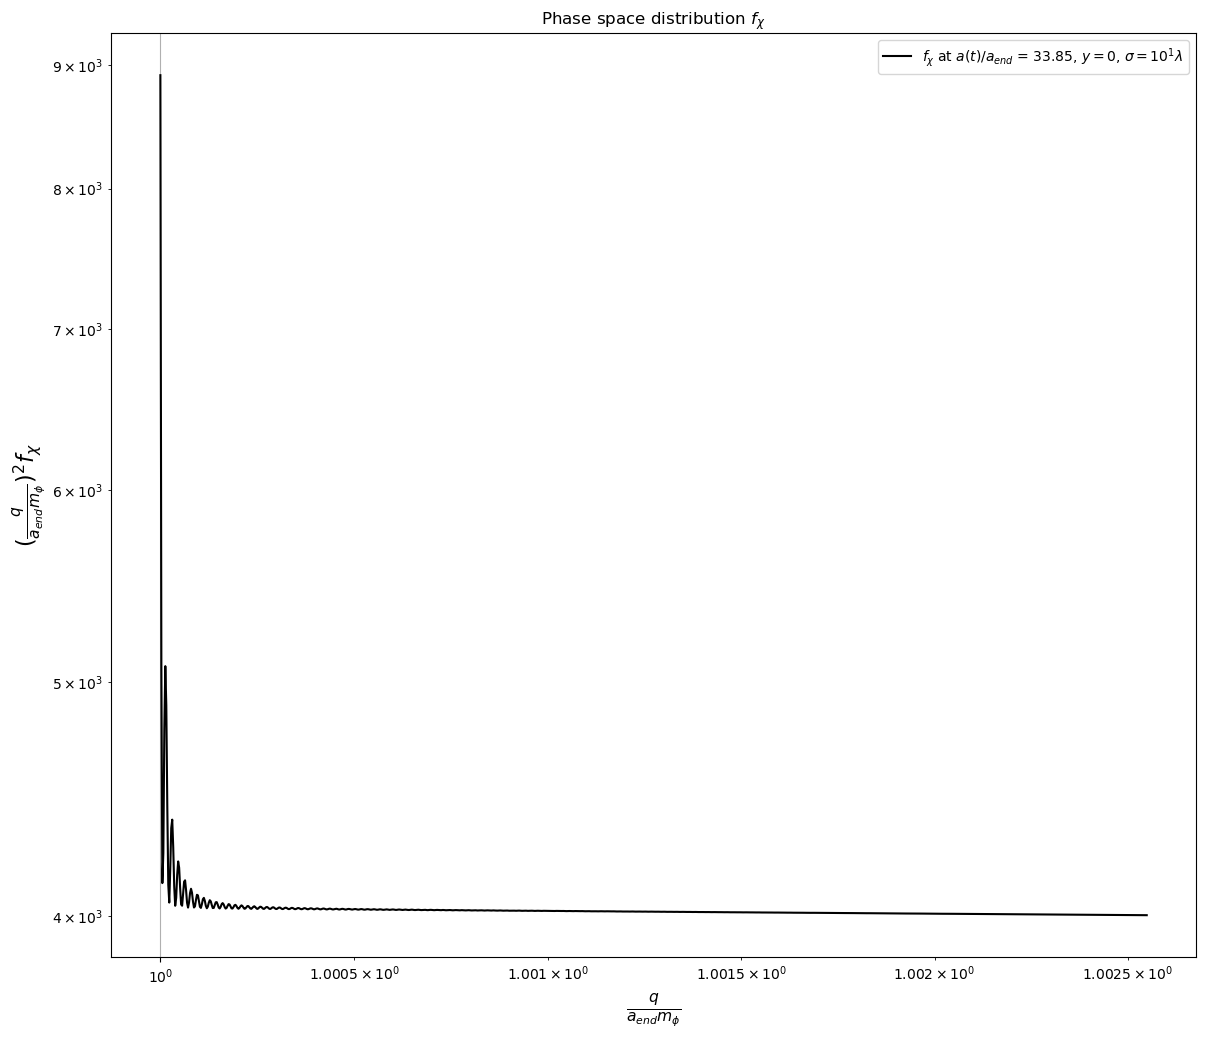

33.854082395000965


In [23]:
def sol_exponencial(x):
    return (1/2) * (  np.exp(2 * x) - 1  )
#test_corrección = sol3ij(1e-5, 1e-3)
test_solo1 = soloi((10**1)*lambdaa, 10**(-5))
#test_solo2 = soloi((10**4)*lambdaa, 10**(-6))
#test_solo3 = soloi((10**4)*lambdaa, 10**(-7))
#test_solo4 = soloi((10**4)*lambdaa, 10**(-8))

print(test_solo1)



plt.figure(figsize = (14, 12))
p = -1
p2 = -100
#plt.plot(q2, (q2**2)*test_corrección[p, :], color = 'black', label = rf'Solución corregida. $\sigma = ${1}')
plt.plot(test_solo1[1], (test_solo1[1]**2) * test_solo1[0][p, :]/(2*np.pi**2), color = 'black', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{1}}\lambda$')
#plt.plot(q2, (q2**2) * test_solo1[p2, :], color = 'black', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p2]:.2f}, $y = 0$, $\sigma = 10^{{1}}\lambda$')
#plt.plot(q2, (q2**2) * test_solo2[p, :]/(2*np.pi**2), color = 'red', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{2}}\lambda$')
#plt.plot(q2, (q2**2) * test_solo3[p, :]/(2*np.pi**2), color = 'blue', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{3}}\lambda$')
#plt.plot(q2, (q2**2) * test_solo4[p, :]/(2*np.pi**2), color = 'orange', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{4}}\lambda$')
#plt.plot()
#plt.plot(q2, (q2**2) * test_solo[500, :], color = 'blue', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[500]:.2f}')
plt.title(rf'Phase space distribution $f_\chi$')
plt.xlabel(r'$ \frac{q}{a_{end} m_\phi} $', size = 16)
plt.ylabel(r'$ (\frac{q}{a_{end} m_\phi})^2 f_\chi$', size = 16)
plt.legend()
plt.grid()
plt.yscale('log')
plt.xscale('log')

plt.savefig('comparacion.png')
plt.show()
print(a_norm_filt[-1])
#print(test_corrección)

In [24]:
def sol_exponencial(x):
    return (1/2) * (  np.exp(2 * x) - 1  )

correccion_expo1 = sol_exponencial(test_solo1[:, :])
correccion_expo2 = sol_exponencial(test_solo2[:, :])
correccion_expo3 = sol_exponencial(test_solo3[:, :])
correccion_expo4 = sol_exponencial(test_solo4[:, :])


plt.figure(figsize = (14, 12))
p = -1
p2 = -100
#plt.plot(q2, (q2**2)*test_corrección[p, :], color = 'black', label = rf'Solución corregida. $\sigma = ${1}')
#plt.plot(q2, (q2**2) * correccion_expo1[p, :]/(2*np.pi**2), color = 'black', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{1}}\lambda$')
#plt.plot(q2, (q2**2) * test_solo1[p2, :], color = 'black', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p2]:.2f}, $y = 0$, $\sigma = 10^{{1}}\lambda$')
#plt.plot(q2, (q2**2) * correccion_expo2[p, :]/(2*np.pi**2), color = 'red', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{2}}\lambda$')
#plt.plot(q2, (q2**2) * correccion_expo3[p, :]/(2*np.pi**2), color = 'blue', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{3}}\lambda$')
#plt.plot(q2, (q2**2) * correccion_expo4[p, :]/(2*np.pi**2), color = 'orange', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{4}}\lambda$')
plt.plot()
#plt.plot(q2, (q2**2) * test_solo[500, :], color = 'blue', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[500]:.2f}')
plt.title(rf'Phase space distribution $f_\chi$')
plt.xlabel(r'$ \frac{q}{a_{end} m_\phi} $', size = 16)
plt.ylabel(r'$ (\frac{q}{a_{end} m_\phi})^2 f_\chi$', size = 16)
plt.legend()
plt.grid()
plt.yscale('log')
#plt.xscale('log')

plt.savefig('comparacion.png')
plt.show()
print(a_norm_filt[-1])
#print(test_corrección)

TypeError: tuple indices must be integers or slices, not tuple

In [ ]:
#rho_phi = np.array(rho_phi)
#rho_phi_avaraged = np.array(rho_phi_avaraged)
#plt.plot(t[t>t_end], rho_phi_avaraged[t>t_end], color = 'red')
#plt.plot(t[t>t_end], rho_phi[t>t_end], color = 'black')
#plt.yscale('log')
#plt.show()

In [ ]:
data_all_correction = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\solij_array.npy', allow_pickle=True)
data_all_solo = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\soloi_array.npy', allow_pickle=True)


data_2_correction = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\solij_array2.npy', allow_pickle=True)
data_2_solo = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\soloi_array2.npy', allow_pickle=True)

data_3_correction = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\solij_array3.npy', allow_pickle=True)
data_3_solo = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\soloi_array3.npy', allow_pickle=True)

data_4_correction = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\solij_array4.npy', allow_pickle=True)
data_4_solo = np.load(r'C:\Users\jcarl\Documents\Maestría\Tesis\Boltzmann\f_chi\Remoto\soloi_array4.npy', allow_pickle=True)

In [ ]:
#q2_min = np.min(a_norm_filt)

#q2_max = np.max(a_norm_filt) #Tengo que ver si conviene este q_max
#N2_q = 40

#q2 = np.linspace(q2_min, q2_max, N2_q)

#q2 = np.array(q2)


#plt.plot(q2, (q2**2) * data_4_correction[12][-1,:], color = 'red', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{4}}\lambda$')
#plt.plot(q2, (q2**2) * data_4_solo[0][-1,:], color = 'black', ls = 'dashed', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[p]:.2f}, $y = 0$, $\sigma = 10^{{4}}\lambda$')
#plt.plot(q2, (q2**2) * test_solo[500, :], color = 'blue', ls = 'solid', label = rf'$f_\chi$ at $a(t)/a_{{end}}$ = {a_norm[500]:.2f}')
#plt.title(rf'Phase space distribution $f_\chi$')
#plt.xlabel(r'$ \frac{q}{a_{end} m_\phi} $', size = 16)
#plt.ylabel(r'$ (\frac{q}{a_{end} m_\phi})^2 f_\chi$', size = 16)
#plt.legend()
#plt.grid()
#plt.yscale('log')
#plt.xscale('log')
#plt.show()
#print(a_norm_filt[-1])
#print(test_corrección)

In [ ]:
#print(test_corrección)

In [ ]:
#list(range(1,2))

In [ ]:
#def acoples(n):
#    resultado = []
#    for i in range(0, n+1,2):
#        resultado.append(10**(-i))
#    return resultado

#couplings = acoples(2)
#solij_array = np.empty((len(couplings), len(couplings)), dtype=object)
#soloi_array = np.empty(len(couplings), dtype=object)

#count1 = 0
#for i, sigma_val in enumerate(couplings):
#    for j, y_val in enumerate(couplings):
#        print(f'Empezando solución corregida para sigma = {sigma_val:.1e}, y = {y_val:.1e}')
#        temp = sol3ij(sigma_val, y_val)
#        solij_array[i, j] = temp
#        count1 += 1
#        print(f'Resultado guardado ({count1}/{len(couplings)*len(couplings)})')




#count2 = 0
#for i, sigma_val in enumerate(couplings):
#    print(f'Empezando solución sin corregir para sigma = {sigma_val:.1e}')
#    temp = soloi(sigma_val)
#    soloi_array[i] = temp
#    count2 += 1
#    print(f'Resultado guardado ({count2}/{len(couplings)})')




In [ ]:
#np.save('solij_array.npy', solij_array)
#np.save('soloi_array.npy', soloi_array)

In [ ]:
#plt.figure(figsize = (12, 12))
#p = -1
#b = -1
#c = 1

#plt.plot(q2, (q2**2)*solij_array[b, c][p, :], color = 'black', label = rf'Solución corregida. $\sigma = ${1}')
##plt.plot(q2, (q2**2) * soloi_array[b][p, :], color = 'red', ls = 'dotted', label = 'Solución con corrección')
##plt.title(rf'$a(t)/a_{{end}}$ = {a_norm[a]:.2f}')
#plt.xlabel(r'$ \frac{q}{a_{end} m_\phi} $', size =15 )
#plt.ylabel(r'$ (\frac{q}{a_{end} m_\phi})^2 f_\chi$', size = 15)
#plt.legend()
#plt.grid()
#plt.yscale('log')
#plt.xscale('log')

#plt.savefig('comparacion.png')
#plt.show()

In [ ]:
#plt.figure(figsize = (12, 12))
#a = -1

#plt.plot(q2, (q2**2)*sol66[a, :], color = 'black', label = rf'Solución corregida. $\sigma = ${a6}')
#plt.plot(q2, (q2**2) * solo6[a, :], color = 'red', ls = 'dotted', label = 'Solución con corrección')
#plt.title(rf'$a(t)/a_{{end}}$ = {a_norm[a]:.2f}')
#plt.xlabel(r'$ \frac{q}{a_{end} m_\phi} $', size =15 )
#plt.ylabel(r'$ (\frac{q}{a_{end} m_\phi})^2 f_\chi$', size = 15)
#plt.legend()
#plt.grid()
#plt.yscale('log')
#plt.xscale('log')

#plt.savefig('comparacion.png')
#plt.show()

In [ ]:
#diferencia = f_chi_q_1 - f_chi_q_2

#for i in range(len(t)):
#    for j in range(len(q2)):
#        if diferencia[i, j] != 0.:
#            print('Algo está bien')
#            print(f'La ubicación es i = {i}, j = {j}, diferencia = {diferencia[i,j]}')